# ðŸ“‰ Notebook 08: Tanh Saturation Deep Dive â€” Understanding Diminishing Returns

Every marketer knows: the more you spend, the less each additional dollar returns. Saturation curves capture this mathematically. This notebook shows exactly how.

We focus on the **two-parameter tanh formulation** used in production MMM systems:

$$\text{saturated}(x) = \tanh\!\left(\frac{x}{\text{scalar} \times \alpha}\right)$$

where `scalar` is fixed from data (max activity) and `alpha` is estimated by the model.

### What you'll learn:

1. **Why saturation matters** â€” linear vs. realistic response
2. **The tanh function** â€” mathematical walkthrough with visualizations
3. **Two parameters explained** â€” scalar (data-driven) and alpha (estimated)
4. **Comparing saturation functions** â€” tanh vs. logistic vs. Hill
5. **PyMC-Marketing saturation classes** — all four built-in functions
6. **Fitting MMM with different saturations** — Tanh vs. Logistic comparison
7. **Response curves from a fitted model** — real posterior uncertainty
8. **Full pipeline** — spend → adstock → saturation → contribution
9. **Marginal response** — derivatives and optimal spend zones
10. **Posterior uncertainty** — fan charts from parameter uncertainty
11. **Practical examples** — five channels with different saturation profiles
12. **Numerical stability** — the clipping trick that prevents overflow

---

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': '#FAFBFC', 'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D0D7DE', 'axes.grid': True, 'grid.alpha': 0.3,
    'grid.color': '#D0D7DE', 'legend.framealpha': 0.9, 'legend.edgecolor': '#D0D7DE',
})
COLORS = ['#2563EB', '#F97316', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']

df = pd.read_csv('data/sample_mmm_weekly.csv', parse_dates=['date'])
MEDIA_COLS = ['tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend']
TARGET_COL = 'revenue'
print(f'Loaded {len(df)} rows, {len(MEDIA_COLS)} media channels')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

Loaded 104 rows, 5 media channels
Date range: 2023-01-02 to 2024-12-23


---

## 1. Why Saturation Matters

Without saturation, a model assumes that doubling your spend always doubles the return. In reality, audiences get fatigued, inventory fills up, and each additional impression is worth less. The chart below shows the difference.

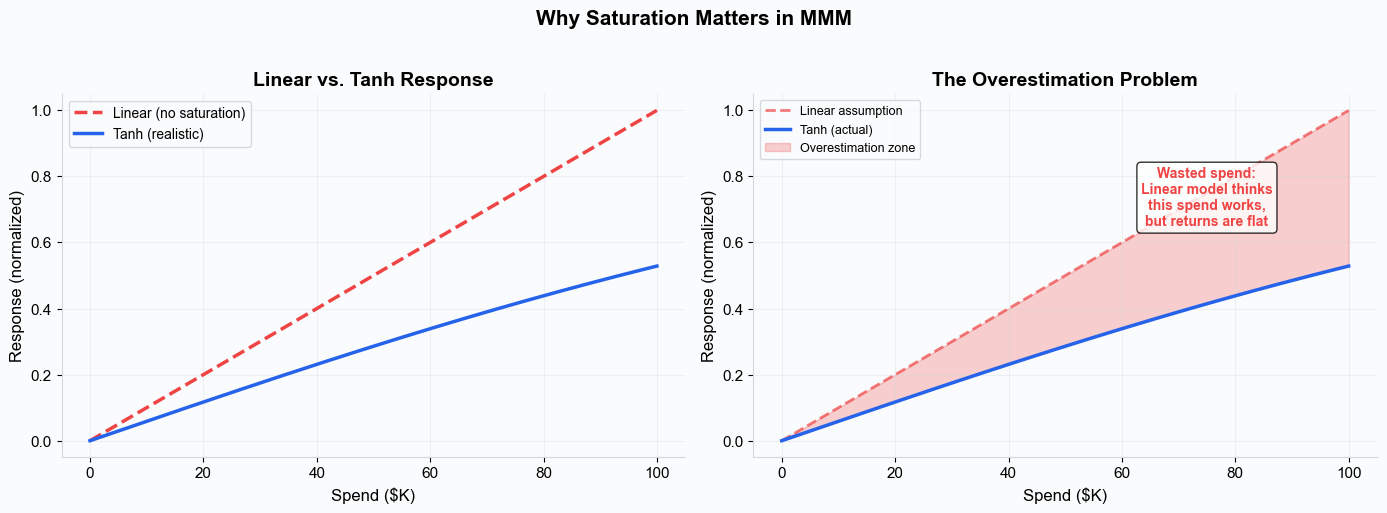

Without saturation, optimizers will recommend pouring money into already-saturated channels.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

spend = np.linspace(0, 100, 500)
scalar = 100.0
alpha = 1.7
linear_response = spend / scalar  # normalized linear
tanh_response = np.tanh(spend / (scalar * alpha))

# Panel 1: Side by side
ax = axes[0]
ax.plot(spend, linear_response, color=COLORS[3], linewidth=2.5, linestyle='--', label='Linear (no saturation)')
ax.plot(spend, tanh_response, color=COLORS[0], linewidth=2.5, label='Tanh (realistic)')
ax.set_xlabel('Spend ($K)')
ax.set_ylabel('Response (normalized)')
ax.set_title('Linear vs. Tanh Response')
ax.legend(fontsize=10)

# Panel 2: The "wasted spend" zone
ax = axes[1]
ax.plot(spend, linear_response, color=COLORS[3], linewidth=2, linestyle='--', alpha=0.7, label='Linear assumption')
ax.plot(spend, tanh_response, color=COLORS[0], linewidth=2.5, label='Tanh (actual)')
ax.fill_between(spend, tanh_response, linear_response,
                where=linear_response > tanh_response,
                alpha=0.25, color=COLORS[3], label='Overestimation zone')
ax.annotate('Wasted spend:\nLinear model thinks\nthis spend works,\nbut returns are flat',
           xy=(75, 0.65), fontsize=10, color=COLORS[3], fontweight='bold',
           ha='center',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlabel('Spend ($K)')
ax.set_ylabel('Response (normalized)')
ax.set_title('The Overestimation Problem')
ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Why Saturation Matters in MMM', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/08_why_saturation_matters.png', dpi=180, bbox_inches='tight')
plt.show()
print('Without saturation, optimizers will recommend pouring money into already-saturated channels.')

---

## 2. The Tanh Function

The hyperbolic tangent maps any input to the range (0, 1) for positive inputs:

$$\text{saturated}(x) = \tanh\!\left(\frac{x}{\text{scalar} \times \alpha}\right)$$

- **scalar** = maximum observed activity for the channel (fixed from data, normalizes the input to roughly [0, 1])
- **alpha** = shape parameter (estimated by the model, Gamma prior with mu=1.7)
  - Small alpha (< 1): rapid saturation, channel hits diminishing returns quickly
  - Large alpha (> 2): gradual saturation, channel stays close to linear longer

Let's visualize the effect of different alpha values.

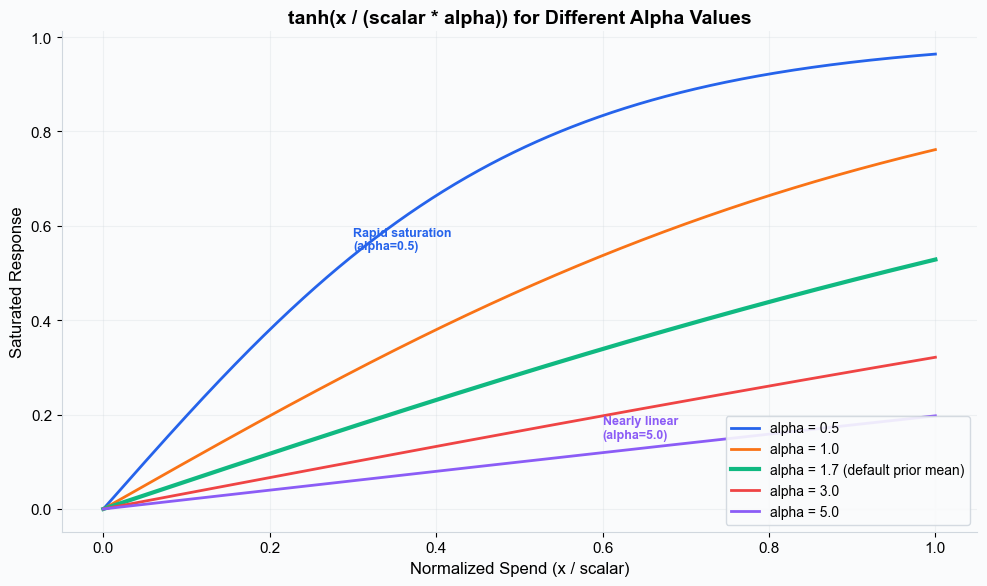

Key insight: alpha=1.7 (the default prior) gives moderate diminishing returns.
Most channels in practice have alpha between 1.0 and 3.0.


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 1, 500)  # normalized spend (0 to scalar)
alphas = [0.5, 1.0, 1.7, 3.0, 5.0]

for i, alpha in enumerate(alphas):
    y = np.tanh(x / alpha)
    style = '-' if alpha != 1.7 else '-'
    lw = 2 if alpha != 1.7 else 3
    label = f'alpha = {alpha}'
    if alpha == 1.7:
        label += ' (default prior mean)'
    ax.plot(x, y, color=COLORS[i % len(COLORS)], linewidth=lw, label=label)

ax.set_xlabel('Normalized Spend (x / scalar)')
ax.set_ylabel('Saturated Response')
ax.set_title('tanh(x / (scalar * alpha)) for Different Alpha Values')
ax.legend(fontsize=10, loc='lower right')

# Annotations
ax.annotate('Rapid saturation\n(alpha=0.5)', xy=(0.3, 0.55), fontsize=9,
           color=COLORS[0], fontweight='bold')
ax.annotate('Nearly linear\n(alpha=5.0)', xy=(0.6, 0.15), fontsize=9,
           color=COLORS[4], fontweight='bold')

plt.tight_layout()
plt.savefig('images/08_tanh_alpha_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Key insight: alpha=1.7 (the default prior) gives moderate diminishing returns.')
print('Most channels in practice have alpha between 1.0 and 3.0.')

---

## 3. Two Parameters Explained

The tanh formulation has exactly two parameters:

| Parameter | Role | Source | Effect |
|-----------|------|--------|--------|
| **scalar** | Normalizes input | Fixed from data (max activity) | Horizontal stretch â€” determines the scale of the x-axis |
| **alpha** | Controls shape | Estimated (Gamma prior, mu=1.7) | Vertical curve shape â€” how quickly saturation sets in |

Let's visualize each parameter's effect independently.

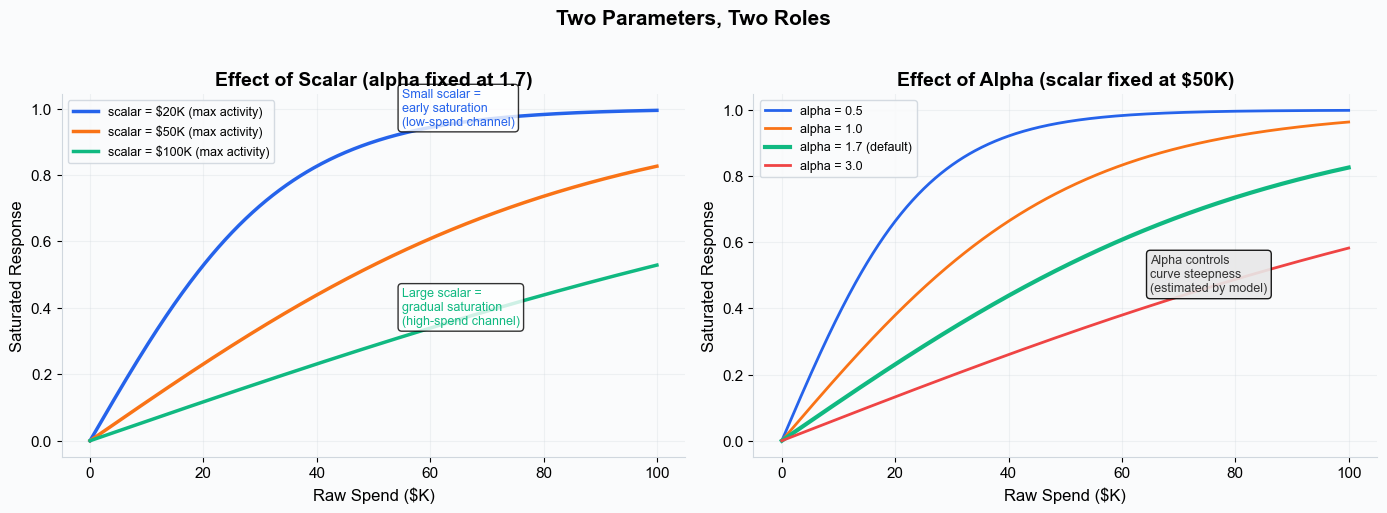

Scalar stretches the curve horizontally (from data). Alpha bends the curve vertically (from estimation).


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Varying scalar (fixed alpha=1.7)
ax = axes[0]
alpha_fixed = 1.7
spend_raw = np.linspace(0, 100000, 500)
scalars = [20000, 50000, 100000]

for i, s in enumerate(scalars):
    y = np.tanh(spend_raw / (s * alpha_fixed))
    ax.plot(spend_raw / 1000, y, color=COLORS[i], linewidth=2.5,
           label=f'scalar = ${s/1000:.0f}K (max activity)')

ax.set_xlabel('Raw Spend ($K)')
ax.set_ylabel('Saturated Response')
ax.set_title('Effect of Scalar (alpha fixed at 1.7)')
ax.legend(fontsize=9)
ax.annotate('Small scalar =\nearly saturation\n(low-spend channel)',
           xy=(55, 0.95), fontsize=9, color=COLORS[0],
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.annotate('Large scalar =\ngradual saturation\n(high-spend channel)',
           xy=(55, 0.35), fontsize=9, color=COLORS[2],
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Panel 2: Varying alpha (fixed scalar=50000)
ax = axes[1]
scalar_fixed = 50000
alphas_show = [0.5, 1.0, 1.7, 3.0]

for i, a in enumerate(alphas_show):
    y = np.tanh(spend_raw / (scalar_fixed * a))
    lw = 3 if a == 1.7 else 2
    ax.plot(spend_raw / 1000, y, color=COLORS[i], linewidth=lw,
           label=f'alpha = {a}{" (default)" if a == 1.7 else ""}')

ax.set_xlabel('Raw Spend ($K)')
ax.set_ylabel('Saturated Response')
ax.set_title('Effect of Alpha (scalar fixed at $50K)')
ax.legend(fontsize=9)
ax.annotate('Alpha controls\ncurve steepness\n(estimated by model)',
           xy=(65, 0.45), fontsize=9, color='#333',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8E8E8', alpha=0.9))

plt.suptitle('Two Parameters, Two Roles', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/08_two_parameters.png', dpi=180, bbox_inches='tight')
plt.show()
print('Scalar stretches the curve horizontally (from data). Alpha bends the curve vertically (from estimation).')

---

## 4. Comparing Saturation Functions

Different MMM frameworks use different saturation functions. Here we compare the three most common:

| Function | Formula | Used by |
|----------|---------|--------|
| **Tanh** | `tanh(x / (s * a))` | Simba (production) |
| **Logistic** | `1 / (1 + exp(-lambda * (x - mu)))` | PyMC-Marketing default |
| **Hill / Michaelis-Menten** | `x^n / (K^n + x^n)` | Meta Robyn, academic literature |

All three produce S-shaped (or concave) curves. The key differences are in tail behavior and parameterization.

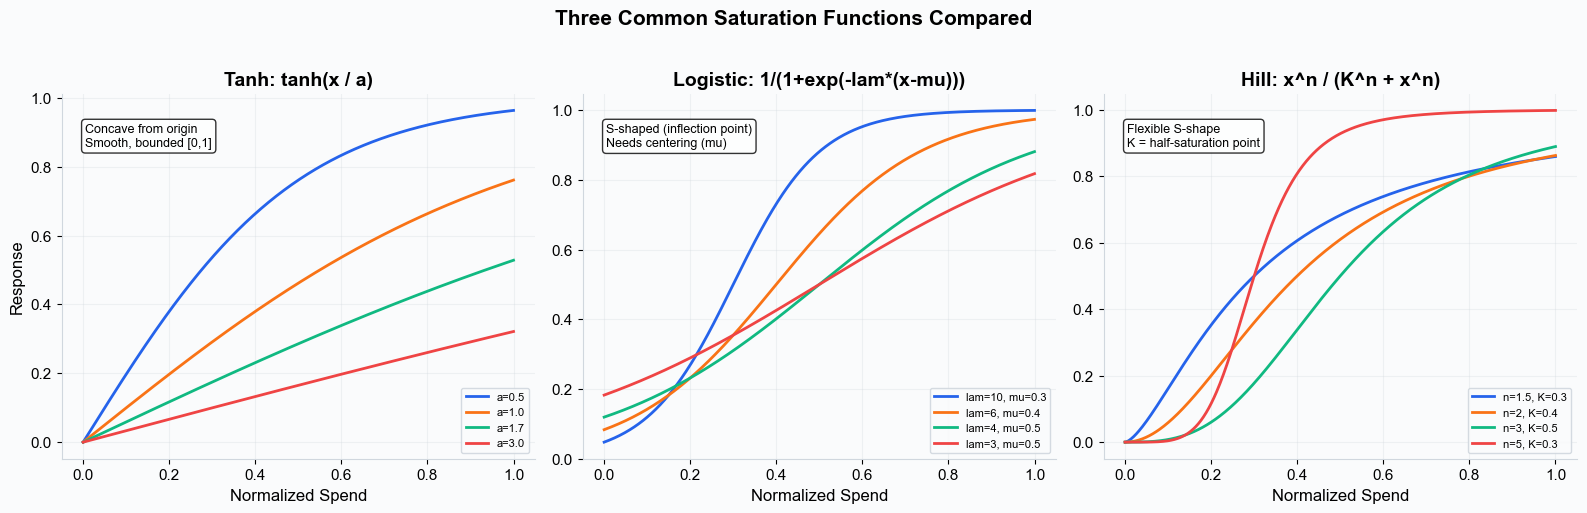

Tanh is the simplest: concave from origin, one shape parameter, numerically stable.
Logistic has an inflection point (S-shape). Hill is the most flexible but hardest to estimate.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.linspace(0, 1, 500)

# --- Panel 1: Tanh ---
ax = axes[0]
for i, a in enumerate([0.5, 1.0, 1.7, 3.0]):
    y = np.tanh(x / a)
    ax.plot(x, y, color=COLORS[i], linewidth=2, label=f'a={a}')
ax.set_title('Tanh: tanh(x / a)')
ax.set_xlabel('Normalized Spend')
ax.set_ylabel('Response')
ax.legend(fontsize=8)
ax.text(0.05, 0.92, 'Concave from origin\nSmooth, bounded [0,1]',
       transform=ax.transAxes, fontsize=9, va='top',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Panel 2: Logistic ---
ax = axes[1]
for i, (lam, mu) in enumerate([(10, 0.3), (6, 0.4), (4, 0.5), (3, 0.5)]):
    y = 1.0 / (1.0 + np.exp(-lam * (x - mu)))
    ax.plot(x, y, color=COLORS[i], linewidth=2, label=f'lam={lam}, mu={mu}')
ax.set_title('Logistic: 1/(1+exp(-lam*(x-mu)))')
ax.set_xlabel('Normalized Spend')
ax.legend(fontsize=8)
ax.text(0.05, 0.92, 'S-shaped (inflection point)\nNeeds centering (mu)',
       transform=ax.transAxes, fontsize=9, va='top',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Panel 3: Hill / Michaelis-Menten ---
ax = axes[2]
for i, (n, K) in enumerate([(1.5, 0.3), (2, 0.4), (3, 0.5), (5, 0.3)]):
    y = x**n / (K**n + x**n)
    ax.plot(x, y, color=COLORS[i], linewidth=2, label=f'n={n}, K={K}')
ax.set_title('Hill: x^n / (K^n + x^n)')
ax.set_xlabel('Normalized Spend')
ax.legend(fontsize=8)
ax.text(0.05, 0.92, 'Flexible S-shape\nK = half-saturation point',
       transform=ax.transAxes, fontsize=9, va='top',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Three Common Saturation Functions Compared', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/08_saturation_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Tanh is the simplest: concave from origin, one shape parameter, numerically stable.')
print('Logistic has an inflection point (S-shape). Hill is the most flexible but hardest to estimate.')

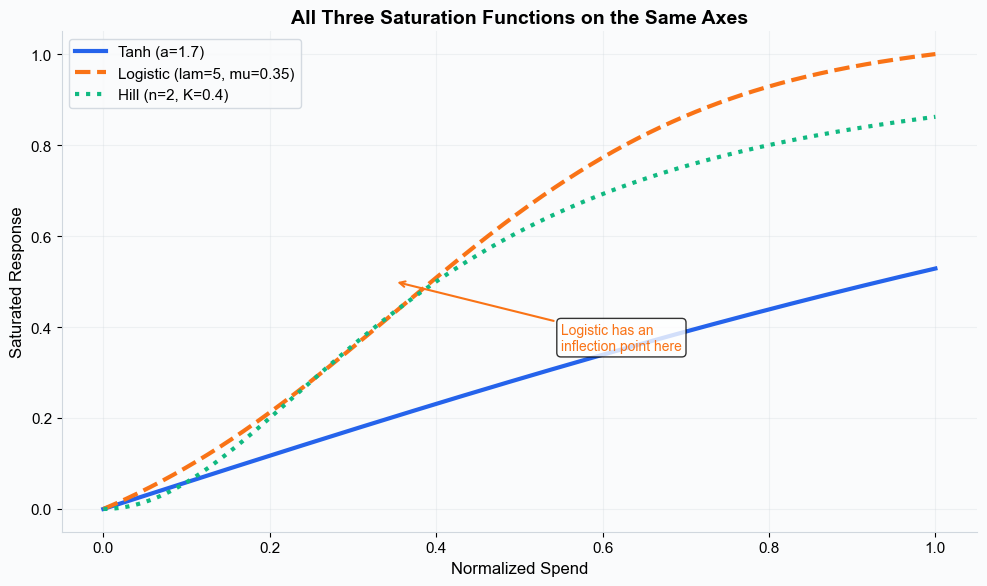

All three can approximate similar shapes, but tanh is concave from origin (no inflection point).


In [6]:
# Overlay all three on the same axes with realistic parameterizations
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, 1, 500)

# Tanh with alpha=1.7 (production default)
y_tanh = np.tanh(x / 1.7)
ax.plot(x, y_tanh, color=COLORS[0], linewidth=3, label='Tanh (a=1.7)')

# Logistic calibrated to match tanh shape approximately
y_logistic = 1.0 / (1.0 + np.exp(-5 * (x - 0.35)))
y_logistic = (y_logistic - y_logistic[0]) / (y_logistic[-1] - y_logistic[0])  # normalize to [0,1]
ax.plot(x, y_logistic, color=COLORS[1], linewidth=3, linestyle='--', label='Logistic (lam=5, mu=0.35)')

# Hill calibrated similarly
y_hill = x**2 / (0.4**2 + x**2)
ax.plot(x, y_hill, color=COLORS[2], linewidth=3, linestyle=':', label='Hill (n=2, K=0.4)')

ax.set_xlabel('Normalized Spend')
ax.set_ylabel('Saturated Response')
ax.set_title('All Three Saturation Functions on the Same Axes')
ax.legend(fontsize=11)

# Annotate key difference
ax.annotate('Logistic has an\ninflection point here',
           xy=(0.35, 0.5), xytext=(0.55, 0.35),
           fontsize=10, color=COLORS[1],
           arrowprops=dict(arrowstyle='->', color=COLORS[1], lw=1.5),
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('images/08_saturation_overlay.png', dpi=180, bbox_inches='tight')
plt.show()
print('All three can approximate similar shapes, but tanh is concave from origin (no inflection point).')

---

## 5. PyMC-Marketing's Saturation Classes

[PyMC-Marketing](https://www.pymc-marketing.io/) provides four saturation transformations out of the box. Each wraps a different functional form and comes with sensible default priors:

| Class | Formula | Parameters | Default Priors |
|-------|---------|------------|----------------|
| **TanhSaturation** | `b * tanh(x / (b * c))` | `b` (max effect), `c` (cost per first unit) | HalfNormal(1), HalfNormal(1) |
| **LogisticSaturation** | `beta * (1-exp(-lam*x)) / (1+exp(-lam*x))` | `lam` (steepness), `beta` (max) | Gamma(3,1), HalfNormal(2) |
| **HillSaturation** | `beta * x^slope / (kappa^slope + x^slope)` | `slope`, `kappa`, `beta` | HalfNormal(1.5) each |
| **MichaelisMentenSaturation** | `alpha * x / (lam + x)` | `alpha` (max), `lam` (half-sat) | Gamma(mu=2,sigma=1), HalfNormal(1) |

Let's use the **functional API** to apply each transformation to sample data and compare their shapes.

TanhSaturation:
  b: Prior("HalfNormal", sigma=1)
  c: Prior("HalfNormal", sigma=1)

LogisticSaturation:
  lam: Prior("Gamma", alpha=3, beta=1)
  beta: Prior("HalfNormal", sigma=2)

HillSaturation:
  slope: Prior("HalfNormal", sigma=1.5)
  kappa: Prior("HalfNormal", sigma=1.5)
  beta: Prior("HalfNormal", sigma=1.5)

MichaelisMentenSaturation:
  alpha: Prior("Gamma", mu=2, sigma=1)
  lam: Prior("HalfNormal", sigma=1)



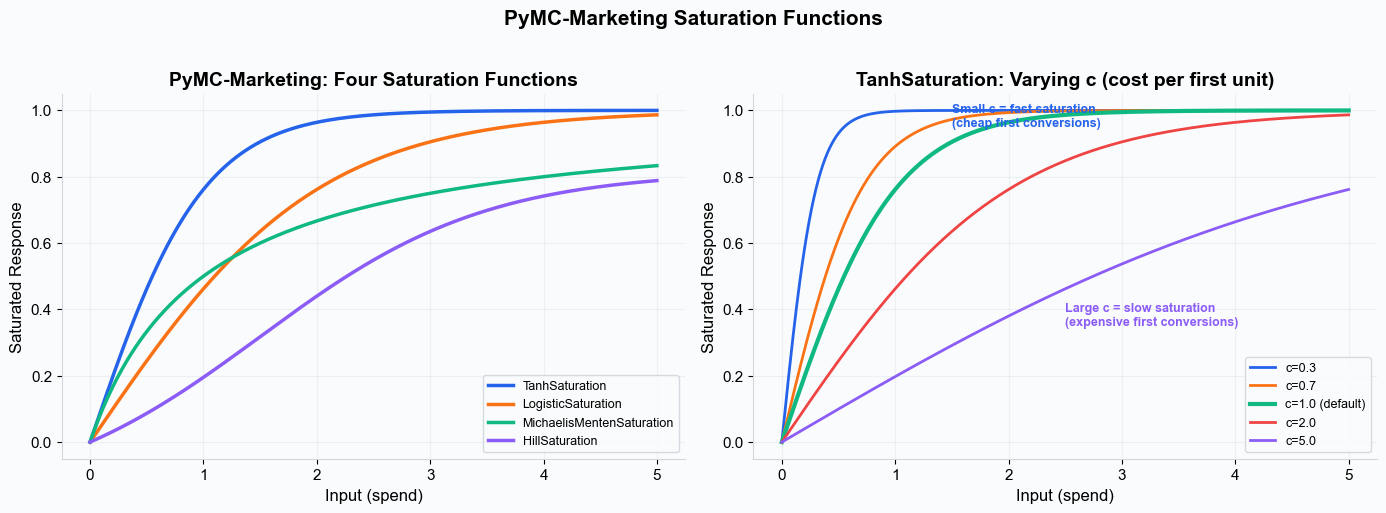

Key insight: TanhSaturation parameter c controls the slope at x=0 (1/c).
This makes it easy to set priors: how much spend for the first conversion?


In [7]:
import xarray as xr
from pymc_marketing.mmm.transformers import (
    tanh_saturation, logistic_saturation, michaelis_menten, hill_saturation_sigmoid
)
from pymc_marketing.mmm import (
    TanhSaturation, LogisticSaturation, HillSaturation, MichaelisMentenSaturation
)

# Print default priors for each class
for cls in [TanhSaturation, LogisticSaturation, HillSaturation, MichaelisMentenSaturation]:
    print(f"{cls.__name__}:")
    for param, prior in cls.default_priors.items():
        print(f"  {param}: {prior}")
    print()

# Use the functional API to compare shapes
# The functional API requires xarray DataArrays with named dims
x_np = np.linspace(0, 5, 500)
x_xr = xr.DataArray(x_np, dims=["obs"])

# Evaluate each saturation function with comparable parameterizations
y_tanh = tanh_saturation(x_xr, b=1.0, c=1.0).eval()
y_logistic = logistic_saturation(x_xr, lam=1.0).eval()
y_mm = michaelis_menten(x_xr, alpha=1.0, lam=1.0).eval()
y_hill = hill_saturation_sigmoid(x_xr, sigma=1.0, beta=1.0, lam=1.5).eval()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: All four on same axes
ax = axes[0]
ax.plot(x_np, y_tanh, color=COLORS[0], linewidth=2.5, label="TanhSaturation")
ax.plot(x_np, y_logistic, color=COLORS[1], linewidth=2.5, label="LogisticSaturation")
ax.plot(x_np, y_mm, color=COLORS[2], linewidth=2.5, label="MichaelisMentenSaturation")
ax.plot(x_np, y_hill, color=COLORS[4], linewidth=2.5, label="HillSaturation")
ax.set_xlabel("Input (spend)")
ax.set_ylabel("Saturated Response")
ax.set_title("PyMC-Marketing: Four Saturation Functions")
ax.legend(fontsize=9)

# Panel 2: Varying parameters within TanhSaturation
ax = axes[1]
for i, c_val in enumerate([0.3, 0.7, 1.0, 2.0, 5.0]):
    y = tanh_saturation(x_xr, b=1.0, c=c_val).eval()
    lw = 3 if c_val == 1.0 else 2
    ax.plot(x_np, y, color=COLORS[i % len(COLORS)], linewidth=lw,
           label=f"c={c_val}{' (default)' if c_val == 1.0 else ''}")
ax.set_xlabel("Input (spend)")
ax.set_ylabel("Saturated Response")
ax.set_title("TanhSaturation: Varying c (cost per first unit)")
ax.legend(fontsize=9)
ax.annotate("Small c = fast saturation\n(cheap first conversions)",
           xy=(1.5, 0.95), fontsize=9, color=COLORS[0], fontweight='bold')
ax.annotate("Large c = slow saturation\n(expensive first conversions)",
           xy=(2.5, 0.35), fontsize=9, color=COLORS[4], fontweight='bold')

plt.suptitle("PyMC-Marketing Saturation Functions", fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("images/08_pymc_saturation_classes.png", dpi=180, bbox_inches='tight')
plt.show()
print("Key insight: TanhSaturation parameter c controls the slope at x=0 (1/c).")
print("This makes it easy to set priors: how much spend for the first conversion?")

---

## 6. Fitting an MMM with Different Saturation Functions

Now let's fit actual Bayesian MMMs using PyMC-Marketing and compare how different saturation choices affect the results.

We use:
- **GeometricAdstock** with `l_max=4` weeks
- Three media channels: TV, Facebook, Google Search
- `chains=2, draws=500, tune=500, cores=1` (Windows-safe MCMC settings)
- Two models: one with **TanhSaturation** and one with **LogisticSaturation**

In [8]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from pymc_marketing.mmm import MMM, GeometricAdstock, TanhSaturation, LogisticSaturation
import arviz as az

CHANNELS = ["tv_spend", "facebook_spend", "google_search_spend"]

# --- Model 1: TanhSaturation ---
mmm_tanh = MMM(
    date_column="date",
    channel_columns=CHANNELS,
    adstock=GeometricAdstock(l_max=4),
    saturation=TanhSaturation(),
    yearly_seasonality=2,
)

X = df[["date"] + CHANNELS].copy()
y = df[TARGET_COL].values

print("Fitting MMM with TanhSaturation...")
idata_tanh = mmm_tanh.fit(
    X=X, y=y,
    chains=2, draws=500, tune=500,
    cores=1,
    random_seed=42,
    progressbar=True,
)
print("TanhSaturation model fitted successfully.")
print(f"Posterior dimensions: {dict(idata_tanh.posterior.dims)}")

Fitting MMM with TanhSaturation...


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, adstock_alpha, saturation_b, saturation_c, gamma_fourier, y_sigma]


Output()

...

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

TanhSaturation model fitted successfully.
Posterior dimensions: {'chain': 2, 'draw': 500, 'channel': 3, 'fourier_mode': 4, 'date': 104}


In [9]:
# --- Model 2: LogisticSaturation ---
mmm_logistic = MMM(
    date_column="date",
    channel_columns=CHANNELS,
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)

print("Fitting MMM with LogisticSaturation...")
idata_logistic = mmm_logistic.fit(
    X=X, y=y,
    chains=2, draws=500, tune=500,
    cores=1,
    random_seed=42,
    progressbar=True,
)
print("LogisticSaturation model fitted successfully.")
print(f"Posterior dimensions: {dict(idata_logistic.posterior.dims)}")

Fitting MMM with LogisticSaturation...


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, y_sigma]


Output()

...

There were 11 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

LogisticSaturation model fitted successfully.
Posterior dimensions: {'chain': 2, 'draw': 500, 'channel': 3, 'fourier_mode': 4, 'date': 104}


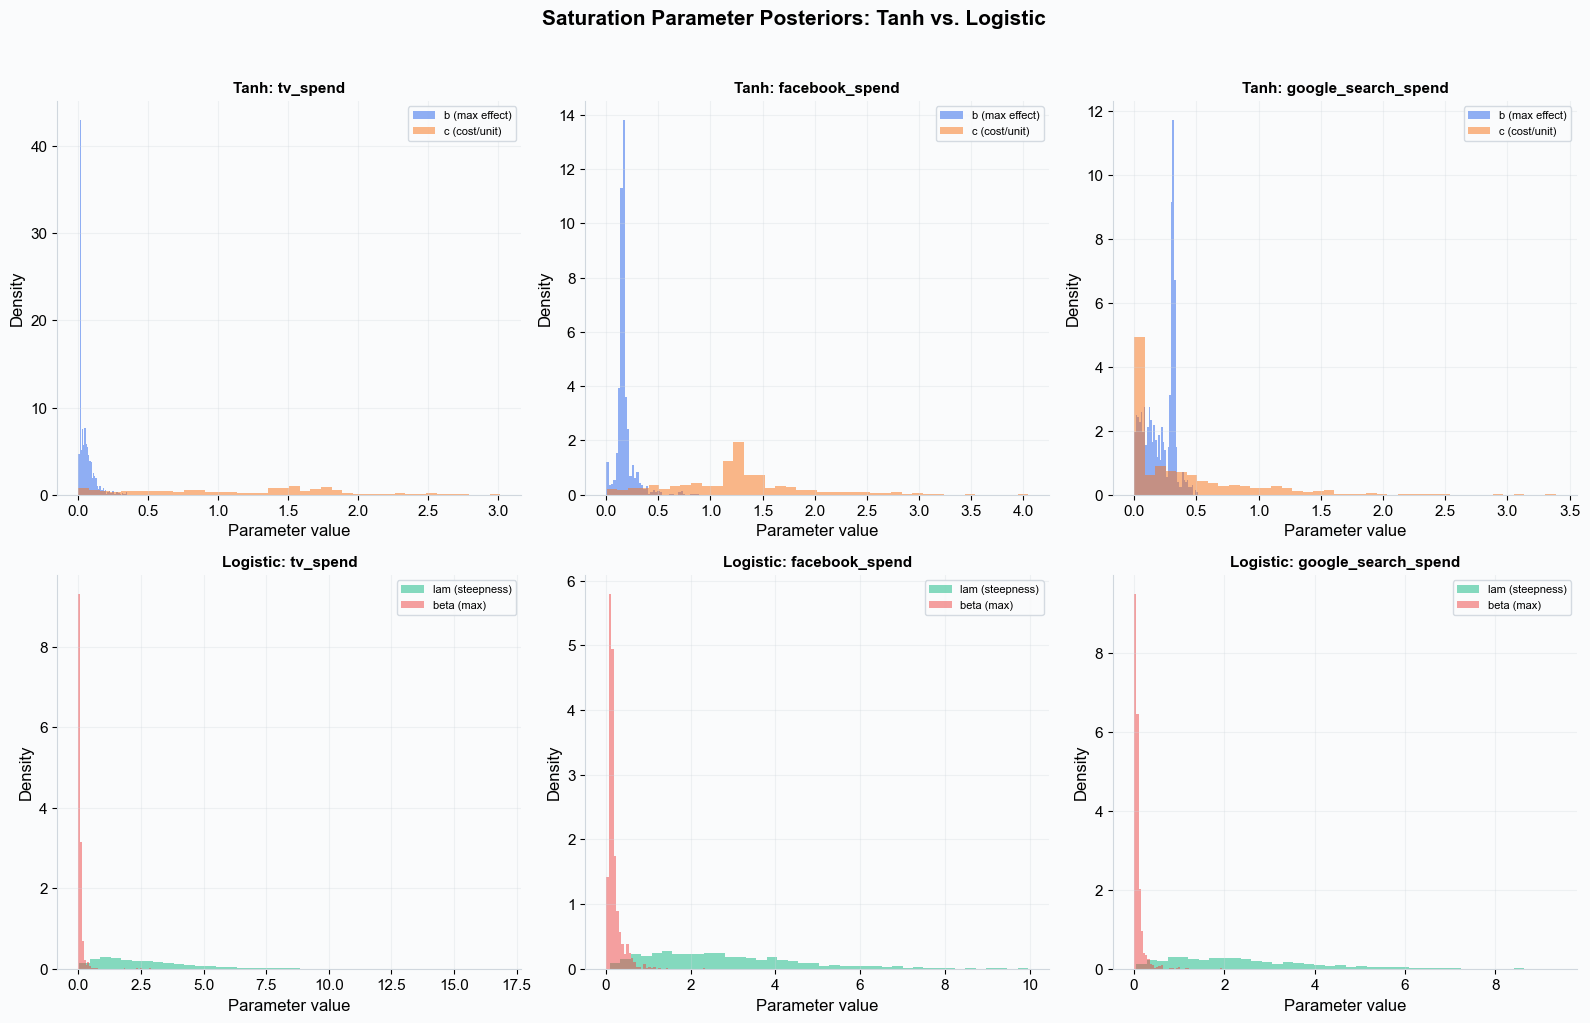

Top row: TanhSaturation parameters (b, c) per channel
Bottom row: LogisticSaturation parameters (lam, beta) per channel


In [10]:
# Compare saturation parameter posteriors
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# TanhSaturation posteriors: b and c per channel
for i, ch in enumerate(CHANNELS):
    ax = axes[0, i]
    b_samples = idata_tanh.posterior["saturation_b"].sel(channel=ch).values.flatten()
    c_samples = idata_tanh.posterior["saturation_c"].sel(channel=ch).values.flatten()
    ax.hist(b_samples, bins=40, alpha=0.5, color=COLORS[0], density=True, label="b (max effect)")
    ax.hist(c_samples, bins=40, alpha=0.5, color=COLORS[1], density=True, label="c (cost/unit)")
    ax.set_title(f"Tanh: {ch}", fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel("Parameter value")
    ax.set_ylabel("Density")

# LogisticSaturation posteriors: lam and beta per channel
for i, ch in enumerate(CHANNELS):
    ax = axes[1, i]
    lam_samples = idata_logistic.posterior["saturation_lam"].sel(channel=ch).values.flatten()
    beta_samples = idata_logistic.posterior["saturation_beta"].sel(channel=ch).values.flatten()
    ax.hist(lam_samples, bins=40, alpha=0.5, color=COLORS[2], density=True, label="lam (steepness)")
    ax.hist(beta_samples, bins=40, alpha=0.5, color=COLORS[3], density=True, label="beta (max)")
    ax.set_title(f"Logistic: {ch}", fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel("Parameter value")
    ax.set_ylabel("Density")

plt.suptitle("Saturation Parameter Posteriors: Tanh vs. Logistic",
            fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("images/08_posterior_comparison.png", dpi=180, bbox_inches='tight')
plt.show()
print("Top row: TanhSaturation parameters (b, c) per channel")
print("Bottom row: LogisticSaturation parameters (lam, beta) per channel")

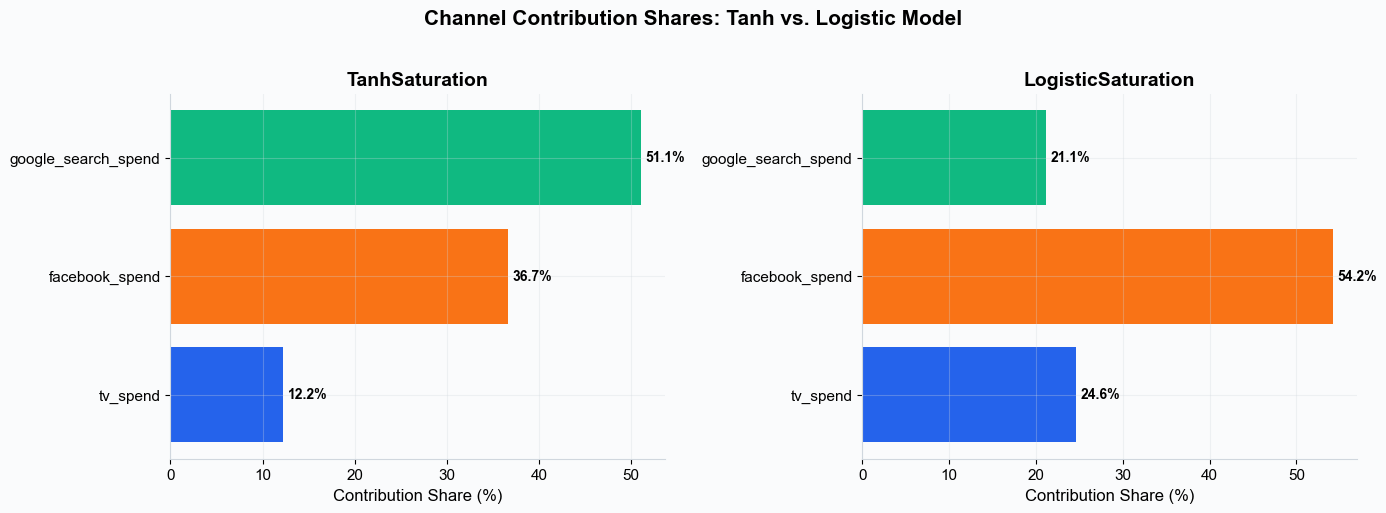

Different saturation functions can shift attribution between channels.
This is why comparing saturation specifications is an important modeling choice.


In [11]:
# Compare channel contribution shares between the two models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mmm_obj, title in [
    (axes[0], mmm_tanh, "TanhSaturation"),
    (axes[1], mmm_logistic, "LogisticSaturation"),
]:
    # Get mean contributions over time
    contributions = mmm_obj.compute_mean_contributions_over_time(
        original_scale=True
    )
    # Sum over time to get total per channel
    total_contrib = contributions[CHANNELS].sum()
    share = total_contrib / total_contrib.sum() * 100

    bars = ax.barh(CHANNELS, share, color=[COLORS[0], COLORS[1], COLORS[2]])
    ax.set_xlabel("Contribution Share (%)")
    ax.set_title(title)
    for bar, val in zip(bars, share):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
               f"{val:.1f}%", va='center', fontsize=10, fontweight='bold')

plt.suptitle("Channel Contribution Shares: Tanh vs. Logistic Model",
            fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("images/08_contribution_comparison.png", dpi=180, bbox_inches='tight')
plt.show()
print("Different saturation functions can shift attribution between channels.")
print("This is why comparing saturation specifications is an important modeling choice.")

---

## 7. Response Curves from a Fitted Model

Once the model is fitted, we can extract the posterior samples of saturation parameters and plot **response curves with real posterior uncertainty** (not simulated). This is the production workflow for interpreting how each channel responds to spend.

PyMC-Marketing provides built-in methods:
- `plot_direct_contribution_curves()` — response curves with HDI bands
- `plot_channel_contribution_share_hdi()` — contribution share uncertainty
- `compute_mean_contributions_over_time()` — time series decomposition

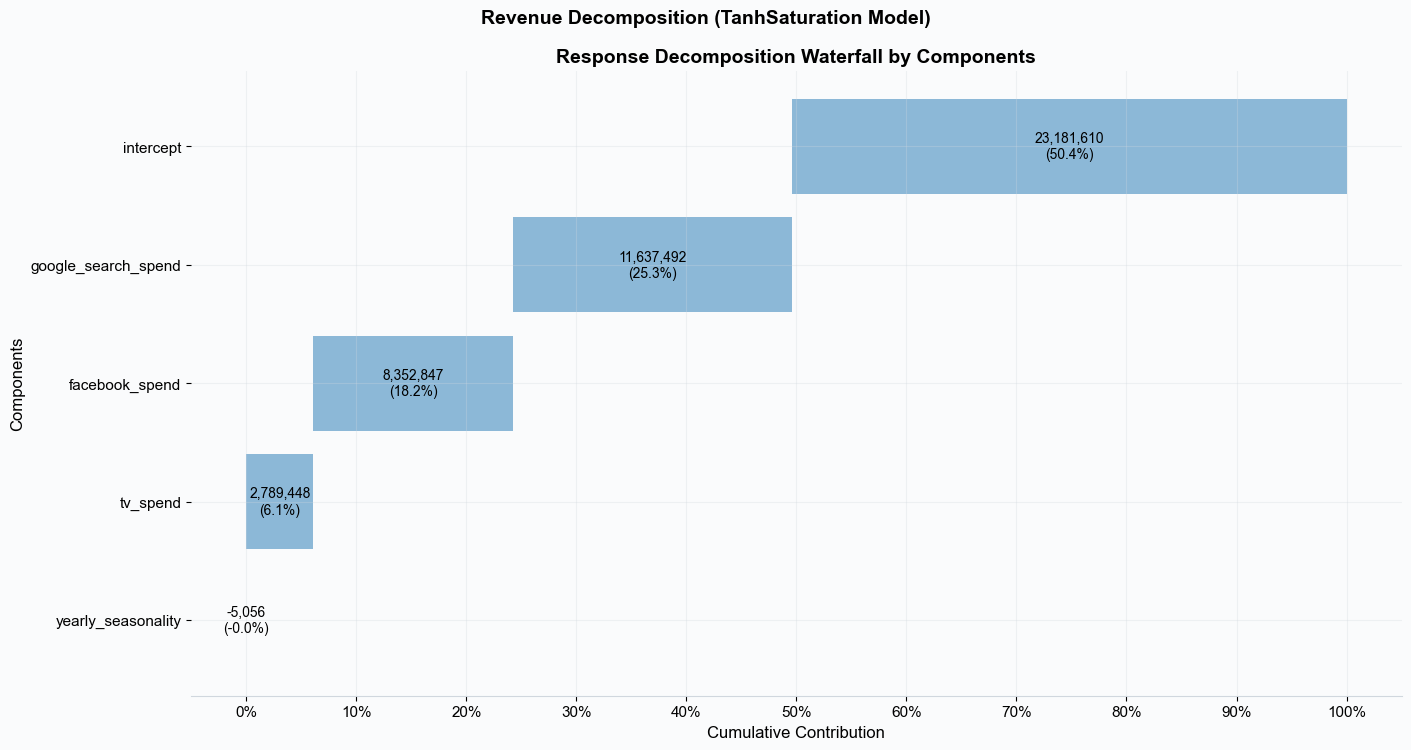

The waterfall shows how each channel and component contributes to total revenue.
This decomposition uses real posterior means from the MCMC fit.


In [12]:
# Plot waterfall decomposition from the fitted TanhSaturation model
fig = mmm_tanh.plot_waterfall_components_decomposition()
fig.suptitle("Revenue Decomposition (TanhSaturation Model)",
            fontweight="bold", fontsize=14, y=1.05)
fig.savefig("images/08_fitted_decomposition.png", dpi=180, bbox_inches="tight")
plt.show()
print("The waterfall shows how each channel and component contributes to total revenue.")
print("This decomposition uses real posterior means from the MCMC fit.")

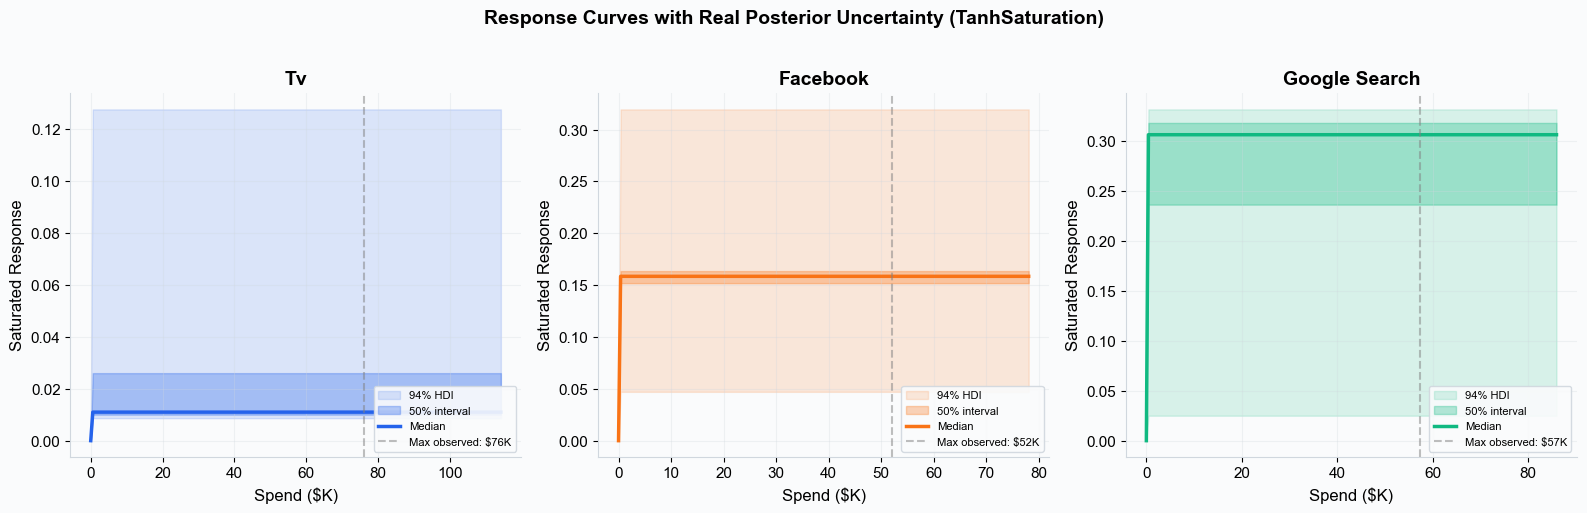

Posterior summaries (TanhSaturation):
tv_spend:
  b (max effect):      median=0.032, 94% HDI=[0.008, 0.215]
  c (cost/first unit): median=1.233, 94% HDI=[0.045, 2.392]
  slope at x=0:        1/c = 0.811

facebook_spend:
  b (max effect):      median=0.159, 94% HDI=[0.035, 0.386]
  c (cost/first unit): median=1.231, 94% HDI=[0.148, 2.612]
  slope at x=0:        1/c = 0.812

google_search_spend:
  b (max effect):      median=0.251, 94% HDI=[0.016, 0.397]
  c (cost/first unit): median=0.222, 94% HDI=[0.040, 1.553]
  slope at x=0:        1/c = 4.496



In [13]:
# Extract posterior samples and build response curves manually
# This gives full control over the visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, ch in enumerate(CHANNELS):
    ax = axes[idx]

    # Get posterior samples of saturation parameters
    b_post = idata_tanh.posterior["saturation_b"].sel(channel=ch).values.flatten()
    c_post = idata_tanh.posterior["saturation_c"].sel(channel=ch).values.flatten()

    # Generate spend range for this channel
    max_spend = df[ch].max()
    spend_grid = np.linspace(0, max_spend * 1.5, 200)

    # Compute response for each posterior sample: b * tanh(x / (b * c))
    n_samples = min(len(b_post), 500)
    responses = np.array([
        b_post[j] * np.tanh(spend_grid / (b_post[j] * c_post[j] + 1e-9))
        for j in range(n_samples)
    ])

    # Fan chart with HDI
    p3 = np.percentile(responses, 3, axis=0)
    p25 = np.percentile(responses, 25, axis=0)
    p50 = np.percentile(responses, 50, axis=0)
    p75 = np.percentile(responses, 75, axis=0)
    p97 = np.percentile(responses, 97, axis=0)

    ax.fill_between(spend_grid / 1000, p3, p97, alpha=0.15, color=COLORS[idx],
                   label="94% HDI")
    ax.fill_between(spend_grid / 1000, p25, p75, alpha=0.3, color=COLORS[idx],
                   label="50% interval")
    ax.plot(spend_grid / 1000, p50, color=COLORS[idx], linewidth=2.5, label="Median")

    # Mark the observed spend range
    ax.axvline(x=max_spend / 1000, color='gray', linestyle='--', alpha=0.5,
             label=f"Max observed: ${max_spend/1000:.0f}K")
    ax.set_xlabel("Spend ($K)")
    ax.set_ylabel("Saturated Response")
    ax.set_title(ch.replace("_spend", "").replace("_", " ").title())
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Response Curves with Real Posterior Uncertainty (TanhSaturation)",
            fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("images/08_manual_response_curves.png", dpi=180, bbox_inches='tight')
plt.show()

# Print posterior summaries
print("Posterior summaries (TanhSaturation):")
print("=" * 60)
for ch in CHANNELS:
    b_post = idata_tanh.posterior["saturation_b"].sel(channel=ch).values.flatten()
    c_post = idata_tanh.posterior["saturation_c"].sel(channel=ch).values.flatten()
    print(f"{ch}:")
    print(f"  b (max effect):      median={np.median(b_post):.3f}, "
          f"94% HDI=[{np.percentile(b_post, 3):.3f}, {np.percentile(b_post, 97):.3f}]")
    print(f"  c (cost/first unit): median={np.median(c_post):.3f}, "
          f"94% HDI=[{np.percentile(c_post, 3):.3f}, {np.percentile(c_post, 97):.3f}]")
    print(f"  slope at x=0:        1/c = {1/np.median(c_post):.3f}")
    print()

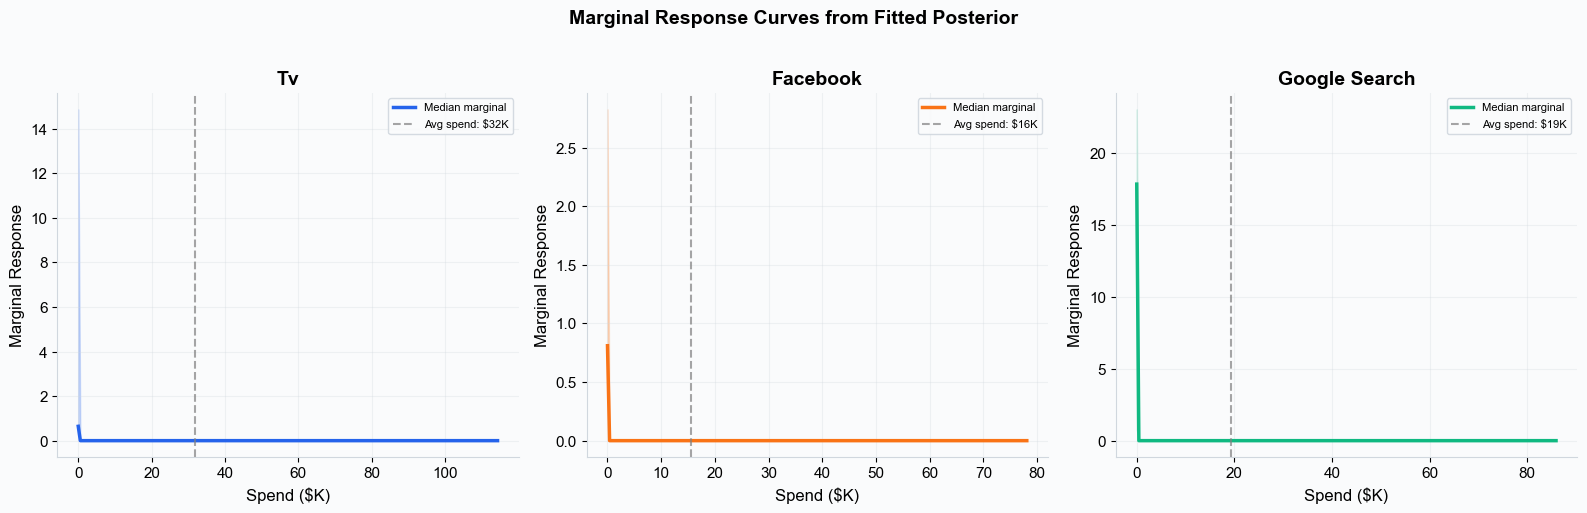

Marginal curves show where each dollar of additional spend yields the most return.
The shaded bands reflect real posterior uncertainty from MCMC sampling.


In [14]:
# Marginal response curves from fitted posterior
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, ch in enumerate(CHANNELS):
    ax = axes[idx]

    b_post = idata_tanh.posterior["saturation_b"].sel(channel=ch).values.flatten()
    c_post = idata_tanh.posterior["saturation_c"].sel(channel=ch).values.flatten()
    max_spend = df[ch].max()
    spend_grid = np.linspace(0, max_spend * 1.5, 200)

    # Marginal: d/dx [b * tanh(x / (b*c))] = (1/c) * sech^2(x / (b*c))
    n_samples = min(len(b_post), 500)
    marginals = np.array([
        (1.0 / (c_post[j] + 1e-9)) * (1 - np.tanh(spend_grid / (b_post[j] * c_post[j] + 1e-9))**2)
        for j in range(n_samples)
    ])

    p3 = np.percentile(marginals, 3, axis=0)
    p50 = np.percentile(marginals, 50, axis=0)
    p97 = np.percentile(marginals, 97, axis=0)

    ax.fill_between(spend_grid / 1000, p3, p97, alpha=0.2, color=COLORS[idx])
    ax.plot(spend_grid / 1000, p50, color=COLORS[idx], linewidth=2.5, label="Median marginal")

    # Mark current average spend
    mean_spend = df[ch].mean()
    ax.axvline(x=mean_spend / 1000, color='gray', linestyle='--', alpha=0.7,
             label=f"Avg spend: ${mean_spend/1000:.0f}K")

    ax.set_xlabel("Spend ($K)")
    ax.set_ylabel("Marginal Response")
    ax.set_title(ch.replace("_spend", "").replace("_", " ").title())
    ax.legend(fontsize=8)

plt.suptitle("Marginal Response Curves from Fitted Posterior",
            fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("images/08_marginal_from_posterior.png", dpi=180, bbox_inches='tight')
plt.show()
print("Marginal curves show where each dollar of additional spend yields the most return.")
print("The shaded bands reflect real posterior uncertainty from MCMC sampling.")

---

## 8. Response Curves from Spend: The Full Pipeline

In a real MMM, raw spend goes through three stages before becoming a contribution:

1. **Adstock** (geometric decay) â€” carry-over from past spend
2. **Saturation** (tanh) â€” diminishing returns
3. **Coefficient** (multiply) â€” scale to revenue units

The order is always: **adstock â†’ saturation â†’ coefficient**. Let's trace one channel through the entire pipeline.

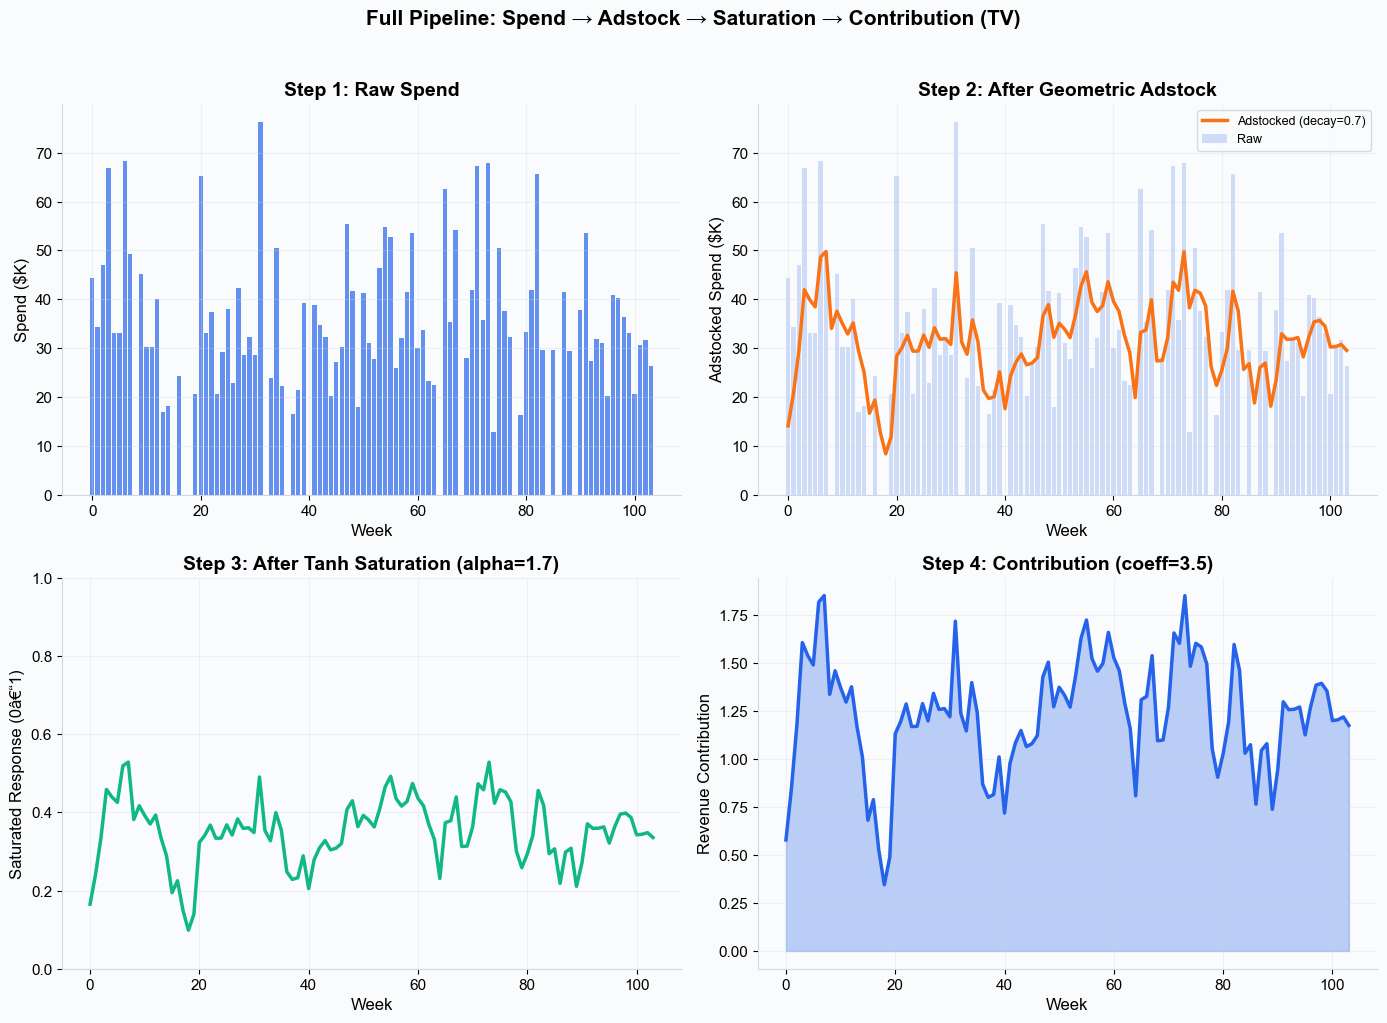

TV channel: scalar=$49,776, alpha=1.7, decay=0.7, coeff=3.5
Mean contribution: 1.23 revenue units per week


In [15]:
def geometric_adstock(x, decay=0.7, max_lag=8):
    """Apply geometric adstock transformation."""
    weights = decay ** np.arange(max_lag)
    weights = weights / weights.sum()
    result = np.convolve(x, weights, mode='full')[:len(x)]
    return result

def tanh_saturation(x, scalar, alpha):
    """Apply tanh saturation: tanh(x / (scalar * alpha))."""
    return np.tanh(x / (scalar * alpha + 1e-9))

# Use TV spend as example
channel = 'tv_spend'
raw_spend = df[channel].values
scalar = raw_spend.max()  # fixed from data
alpha = 1.7
decay = 0.7
coefficient = 3.5  # revenue per unit of saturated effect

# Pipeline
adstocked = geometric_adstock(raw_spend, decay=decay)
scalar_adstocked = adstocked.max()  # scalar from adstocked data
saturated = tanh_saturation(adstocked, scalar_adstocked, alpha)
contribution = saturated * coefficient

# Four-panel visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
weeks = np.arange(len(raw_spend))

ax = axes[0, 0]
ax.bar(weeks, raw_spend / 1000, color=COLORS[0], alpha=0.7, width=0.8)
ax.set_title('Step 1: Raw Spend')
ax.set_ylabel('Spend ($K)')
ax.set_xlabel('Week')

ax = axes[0, 1]
ax.bar(weeks, raw_spend / 1000, color=COLORS[0], alpha=0.2, width=0.8, label='Raw')
ax.plot(weeks, adstocked / 1000, color=COLORS[1], linewidth=2.5, label=f'Adstocked (decay={decay})')
ax.set_title('Step 2: After Geometric Adstock')
ax.set_ylabel('Adstocked Spend ($K)')
ax.set_xlabel('Week')
ax.legend(fontsize=9)

ax = axes[1, 0]
ax.plot(weeks, saturated, color=COLORS[2], linewidth=2.5)
ax.set_title(f'Step 3: After Tanh Saturation (alpha={alpha})')
ax.set_ylabel('Saturated Response (0â€“1)')
ax.set_xlabel('Week')
ax.set_ylim(0, 1)

ax = axes[1, 1]
ax.fill_between(weeks, contribution, color=COLORS[0], alpha=0.3)
ax.plot(weeks, contribution, color=COLORS[0], linewidth=2.5)
ax.set_title(f'Step 4: Contribution (coeff={coefficient})')
ax.set_ylabel('Revenue Contribution')
ax.set_xlabel('Week')

plt.suptitle('Full Pipeline: Spend → Adstock → Saturation → Contribution (TV)',
            fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/08_full_pipeline.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'TV channel: scalar=${scalar_adstocked:,.0f}, alpha={alpha}, decay={decay}, coeff={coefficient}')
print(f'Mean contribution: {contribution.mean():.2f} revenue units per week')

---

## 9. Marginal Response: Where Is the Sweet Spot?

The **marginal return** is the derivative of the response curve â€” it tells you how much additional revenue you get per additional dollar of spend.

For `tanh(x / (s * a))`, the derivative is:

$$\frac{d}{dx}\tanh\!\left(\frac{x}{s \cdot a}\right) = \frac{1}{s \cdot a}\left[1 - \tanh^2\!\left(\frac{x}{s \cdot a}\right)\right]$$

This is highest at x=0 and decays toward zero as spend increases.

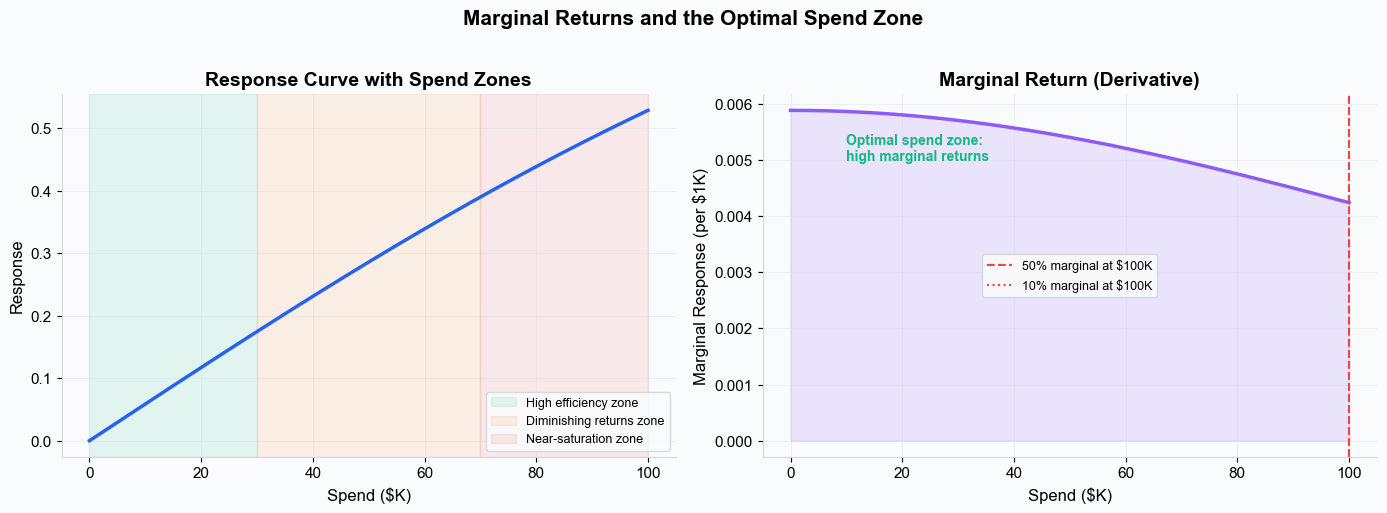

At alpha=1.7: marginal return drops to 50% at $100K spend
At alpha=1.7: marginal return drops to 10% at $100K spend
The optimizer uses these marginal curves to reallocate budget from saturated to unsaturated channels.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

spend = np.linspace(0, 100000, 1000)
scalar = 100000
alpha = 1.7
sa = scalar * alpha

response = np.tanh(spend / sa)
marginal = (1.0 / sa) * (1 - np.tanh(spend / sa)**2)

# Panel 1: Response curve with zones
ax = axes[0]
ax.plot(spend / 1000, response, color=COLORS[0], linewidth=2.5)

# Zones
zone1_end = 30000
zone2_end = 70000
ax.axvspan(0, zone1_end / 1000, alpha=0.1, color=COLORS[2], label='High efficiency zone')
ax.axvspan(zone1_end / 1000, zone2_end / 1000, alpha=0.1, color=COLORS[1], label='Diminishing returns zone')
ax.axvspan(zone2_end / 1000, 100, alpha=0.1, color=COLORS[3], label='Near-saturation zone')
ax.set_xlabel('Spend ($K)')
ax.set_ylabel('Response')
ax.set_title('Response Curve with Spend Zones')
ax.legend(fontsize=9, loc='lower right')

# Panel 2: Marginal response
ax = axes[1]
ax.plot(spend / 1000, marginal * 1000, color=COLORS[4], linewidth=2.5)  # scale for visibility
ax.fill_between(spend / 1000, marginal * 1000, alpha=0.15, color=COLORS[4])

# Find where marginal drops to 50% of max
half_marginal_idx = np.argmin(np.abs(marginal - marginal[0] * 0.5))
half_spend = spend[half_marginal_idx]
ax.axvline(x=half_spend / 1000, color=COLORS[3], linestyle='--', linewidth=1.5,
          label=f'50% marginal at ${half_spend/1000:.0f}K')

# 10% marginal threshold
ten_pct_idx = np.argmin(np.abs(marginal - marginal[0] * 0.1))
ten_spend = spend[ten_pct_idx]
ax.axvline(x=ten_spend / 1000, color=COLORS[3], linestyle=':', linewidth=1.5,
          label=f'10% marginal at ${ten_spend/1000:.0f}K')

ax.annotate('Optimal spend zone:\nhigh marginal returns',
           xy=(10, marginal[100] * 1000 * 0.85), fontsize=10, color=COLORS[2], fontweight='bold')

ax.set_xlabel('Spend ($K)')
ax.set_ylabel('Marginal Response (per $1K)')
ax.set_title('Marginal Return (Derivative)')
ax.legend(fontsize=9)

plt.suptitle('Marginal Returns and the Optimal Spend Zone', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/08_marginal_response.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'At alpha={alpha}: marginal return drops to 50% at ${half_spend/1000:.0f}K spend')
print(f'At alpha={alpha}: marginal return drops to 10% at ${ten_spend/1000:.0f}K spend')
print('The optimizer uses these marginal curves to reallocate budget from saturated to unsaturated channels.')

---

## 10. Posterior Uncertainty: Fan Chart Visualization

In a Bayesian MMM, alpha is not a single number â€” it is a distribution of plausible values (the posterior). This means the response curve is not a single line but a **band of uncertainty**.

We simulate posterior samples for alpha using a Gamma distribution (the default prior) and show how this creates uncertainty in the response curve.

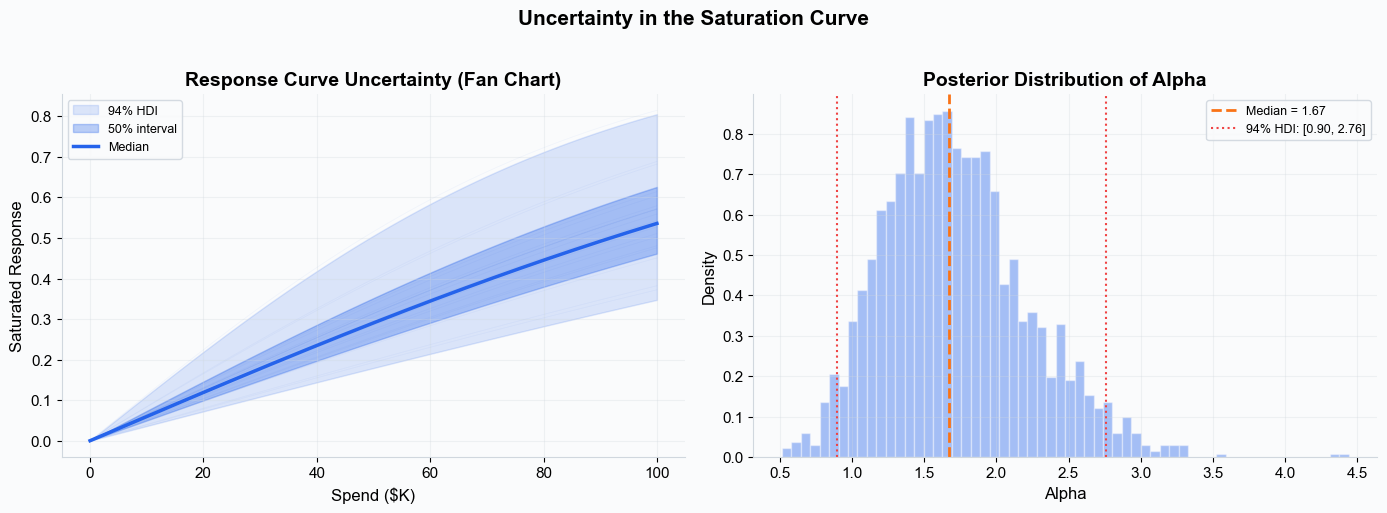

Alpha posterior: median=1.67, 94% HDI=[0.90, 2.76]
Wider posterior = more uncertainty in where saturation kicks in.


In [17]:
np.random.seed(42)

# Simulate posterior samples for alpha
# In practice this comes from MCMC; here we simulate from the prior
mu_alpha = 1.7
sigma_alpha = 0.5  # posterior is tighter than prior
shape_param = (mu_alpha / sigma_alpha) ** 2
scale_param = sigma_alpha ** 2 / mu_alpha
alpha_samples = np.random.gamma(shape_param, scale_param, size=2000)

spend = np.linspace(0, 100000, 500)
scalar = 100000

# Compute response for each posterior sample
responses = np.array([np.tanh(spend / (scalar * a)) for a in alpha_samples])

# Percentiles for fan chart
p5 = np.percentile(responses, 3, axis=0)
p25 = np.percentile(responses, 25, axis=0)
p50 = np.percentile(responses, 50, axis=0)
p75 = np.percentile(responses, 75, axis=0)
p95 = np.percentile(responses, 97, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Fan chart
ax = axes[0]
ax.fill_between(spend / 1000, p5, p95, alpha=0.15, color=COLORS[0], label='94% HDI')
ax.fill_between(spend / 1000, p25, p75, alpha=0.3, color=COLORS[0], label='50% interval')
ax.plot(spend / 1000, p50, color=COLORS[0], linewidth=2.5, label='Median')

# Add a few individual posterior draws
for j in range(20):
    ax.plot(spend / 1000, responses[j], color=COLORS[0], alpha=0.05, linewidth=0.5)

ax.set_xlabel('Spend ($K)')
ax.set_ylabel('Saturated Response')
ax.set_title('Response Curve Uncertainty (Fan Chart)')
ax.legend(fontsize=9)

# Panel 2: Posterior distribution of alpha
ax = axes[1]
ax.hist(alpha_samples, bins=60, density=True, color=COLORS[0], alpha=0.4, edgecolor='white')
ax.axvline(np.median(alpha_samples), color=COLORS[1], linewidth=2, linestyle='--',
          label=f'Median = {np.median(alpha_samples):.2f}')
ax.axvline(np.percentile(alpha_samples, 3), color=COLORS[3], linewidth=1.5, linestyle=':',
          label=f'94% HDI: [{np.percentile(alpha_samples, 3):.2f}, {np.percentile(alpha_samples, 97):.2f}]')
ax.axvline(np.percentile(alpha_samples, 97), color=COLORS[3], linewidth=1.5, linestyle=':')
ax.set_xlabel('Alpha')
ax.set_ylabel('Density')
ax.set_title('Posterior Distribution of Alpha')
ax.legend(fontsize=9)

plt.suptitle('Uncertainty in the Saturation Curve', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/08_posterior_uncertainty.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Alpha posterior: median={np.median(alpha_samples):.2f}, '
      f'94% HDI=[{np.percentile(alpha_samples, 3):.2f}, {np.percentile(alpha_samples, 97):.2f}]')
print('Wider posterior = more uncertainty in where saturation kicks in.')

---

## 11. Practical Examples: Five Channels

Let's look at five realistic channels with different saturation profiles. Each channel has its own alpha (shape) and scalar (from its max spend), producing different response and marginal curves.

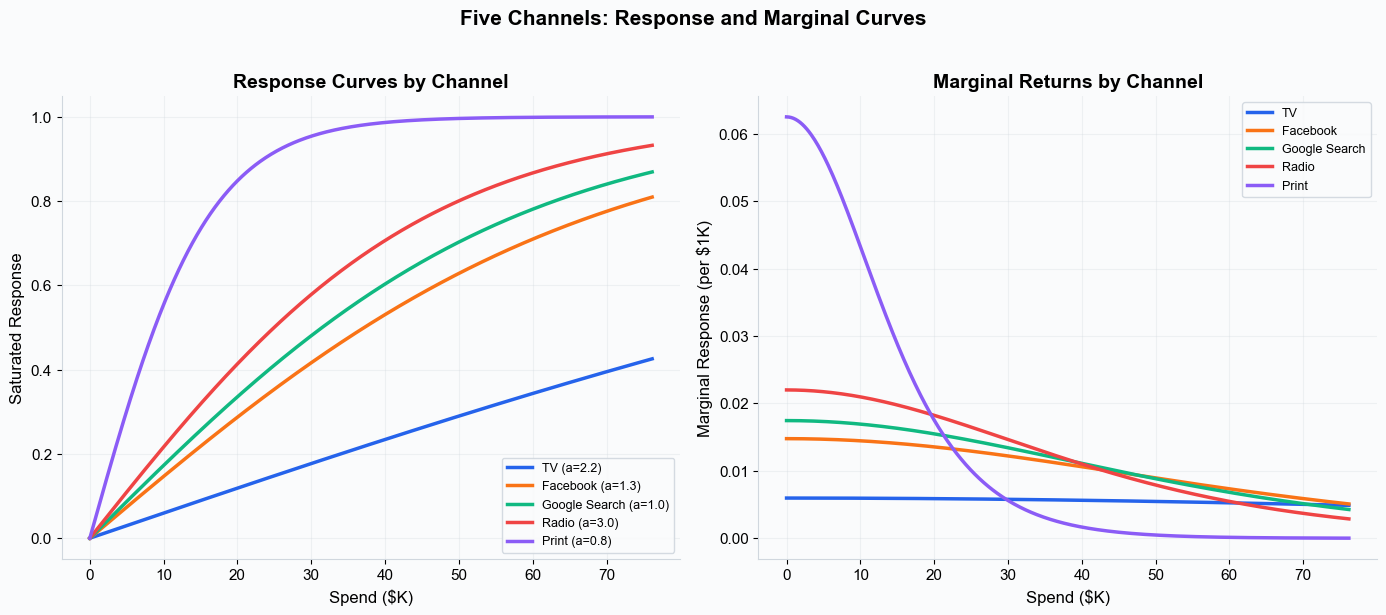

In [18]:
# Channel configurations
channels = {
    'TV':            {'col': 'tv_spend',            'alpha': 2.2, 'color': COLORS[0]},
    'Facebook':      {'col': 'facebook_spend',      'alpha': 1.3, 'color': COLORS[1]},
    'Google Search': {'col': 'google_search_spend',  'alpha': 1.0, 'color': COLORS[2]},
    'Radio':         {'col': 'radio_spend',          'alpha': 3.0, 'color': COLORS[3]},
    'Print':         {'col': 'print_spend',          'alpha': 0.8, 'color': COLORS[4]},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

max_spend_all = max(df[ch['col']].max() for ch in channels.values())
spend_range = np.linspace(0, max_spend_all, 500)

# Panel 1: Response curves
ax = axes[0]
for name, cfg in channels.items():
    scalar = df[cfg['col']].max()
    response = np.tanh(spend_range / (scalar * cfg['alpha'] + 1e-9))
    ax.plot(spend_range / 1000, response, color=cfg['color'], linewidth=2.5,
           label=f'{name} (a={cfg["alpha"]})')

ax.set_xlabel('Spend ($K)')
ax.set_ylabel('Saturated Response')
ax.set_title('Response Curves by Channel')
ax.legend(fontsize=9)

# Panel 2: Marginal curves
ax = axes[1]
for name, cfg in channels.items():
    scalar = df[cfg['col']].max()
    sa = scalar * cfg['alpha'] + 1e-9
    marginal = (1.0 / sa) * (1 - np.tanh(spend_range / sa)**2)
    ax.plot(spend_range / 1000, marginal * 1000, color=cfg['color'], linewidth=2.5,
           label=f'{name}')

ax.set_xlabel('Spend ($K)')
ax.set_ylabel('Marginal Response (per $1K)')
ax.set_title('Marginal Returns by Channel')
ax.legend(fontsize=9)

plt.suptitle('Five Channels: Response and Marginal Curves', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/08_five_channels.png', dpi=180, bbox_inches='tight')
plt.show()

In [19]:
# Summary table with half-saturation and 90% saturation spend
rows = []
for name, cfg in channels.items():
    scalar = df[cfg['col']].max()
    sa = scalar * cfg['alpha']
    
    # Half-saturation: tanh(x/sa) = 0.5 -> x/sa = atanh(0.5) -> x = sa * atanh(0.5)
    half_sat_spend = sa * np.arctanh(0.5)
    # 90% saturation: tanh(x/sa) = 0.9 -> x = sa * atanh(0.9)
    ninety_sat_spend = sa * np.arctanh(0.9)
    
    rows.append({
        'Channel': name,
        'Alpha': cfg['alpha'],
        'Scalar (max spend)': f'${scalar:,.0f}',
        'Half-saturation spend': f'${half_sat_spend:,.0f}',
        '90% saturation spend': f'${ninety_sat_spend:,.0f}',
        'Mean weekly spend': f'${df[cfg["col"]].mean():,.0f}',
    })

summary_df = pd.DataFrame(rows)
print('Saturation Summary Table')
print('=' * 100)
print(summary_df.to_string(index=False))
print()
print('Interpretation:')
print('- Print (alpha=0.8) saturates fastest: 50% response at relatively low spend')
print('- Radio (alpha=3.0) stays linear longest: useful for scaling')
print('- Google Search (alpha=1.0) saturates moderately: typical for high-intent digital')

Saturation Summary Table
      Channel  Alpha Scalar (max spend) Half-saturation spend 90% saturation spend Mean weekly spend
           TV    2.2            $76,184               $92,067             $246,752           $31,920
     Facebook    1.3            $52,056               $37,173              $99,630           $15,512
Google Search    1.0            $57,286               $31,468              $84,338           $19,363
        Radio    3.0            $15,149               $24,965              $66,909            $3,598
        Print    0.8            $20,000                $8,789              $23,556            $2,205

Interpretation:
- Print (alpha=0.8) saturates fastest: 50% response at relatively low spend
- Radio (alpha=3.0) stays linear longest: useful for scaling
- Google Search (alpha=1.0) saturates moderately: typical for high-intent digital


---

## 12. The Numerical Stability Trick

When the input to `tanh` is very large, floating-point math can produce overflow warnings. The production code clips the argument to [-20, 20] before applying tanh:

```python
tanh(clip(x / (scalar * alpha + 1e-9), -20, 20))
```

Since `tanh(20) = 0.9999999...` (effectively 1.0), clipping has zero practical effect on the output but prevents numerical issues. Let's verify.

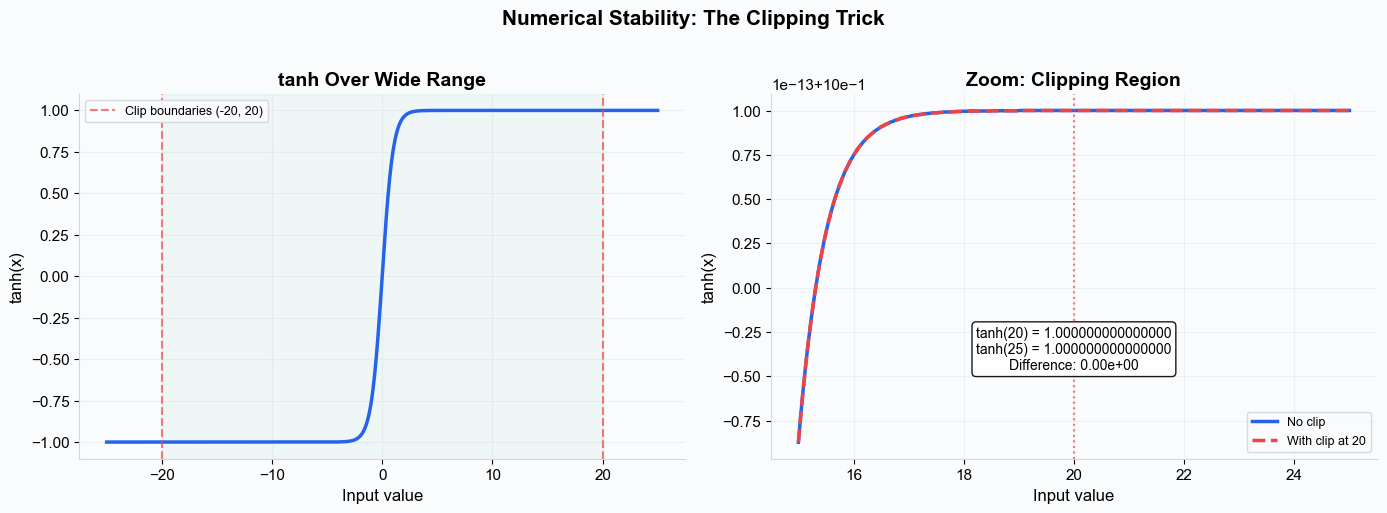

tanh(20) = 1.000000000000000
tanh(25) = 1.000000000000000
Difference: 0.00e+00

Clipping to [-20, 20] is lossless in practice (difference < 1e-17).
It prevents overflow when alpha is very small or spend is very large.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: tanh over a wide range
ax = axes[0]
x_wide = np.linspace(-25, 25, 1000)
y_raw = np.tanh(x_wide)
ax.plot(x_wide, y_raw, color=COLORS[0], linewidth=2.5)
ax.axvspan(-20, 20, alpha=0.05, color=COLORS[2])
ax.axvline(-20, color=COLORS[3], linestyle='--', alpha=0.7, label='Clip boundaries (-20, 20)')
ax.axvline(20, color=COLORS[3], linestyle='--', alpha=0.7)
ax.set_xlabel('Input value')
ax.set_ylabel('tanh(x)')
ax.set_title('tanh Over Wide Range')
ax.legend(fontsize=9)

# Panel 2: Zoom into the clipping region
ax = axes[1]
x_zoom = np.linspace(15, 25, 500)
y_zoom = np.tanh(x_zoom)
y_clipped = np.tanh(np.clip(x_zoom, -20, 20))

ax.plot(x_zoom, y_zoom, color=COLORS[0], linewidth=2.5, label='No clip')
ax.plot(x_zoom, y_clipped, color=COLORS[3], linewidth=2.5, linestyle='--', label='With clip at 20')
ax.axvline(20, color=COLORS[3], linestyle=':', alpha=0.7)
ax.set_xlabel('Input value')
ax.set_ylabel('tanh(x)')
ax.set_title('Zoom: Clipping Region')
ax.legend(fontsize=9)

# Show the precision
ax.text(0.5, 0.3, f'tanh(20) = {np.tanh(20):.15f}\ntanh(25) = {np.tanh(25):.15f}\nDifference: {np.tanh(25) - np.tanh(20):.2e}',
       transform=ax.transAxes, fontsize=10, va='center', ha='center',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle('Numerical Stability: The Clipping Trick', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/08_numerical_stability.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'tanh(20) = {np.tanh(20):.15f}')
print(f'tanh(25) = {np.tanh(25):.15f}')
print(f'Difference: {np.tanh(25) - np.tanh(20):.2e}')
print()
print('Clipping to [-20, 20] is lossless in practice (difference < 1e-17).')
print('It prevents overflow when alpha is very small or spend is very large.')

In [21]:
# Demonstrate the epsilon in the denominator
print('The denominator also adds 1e-9 to prevent division by zero:')
print(f'  scalar * alpha = 0: tanh(1000 / (0 + 1e-9)) = tanh({1000/1e-9:.0e}) = clipped to tanh(20) = {np.tanh(20):.6f}')
print(f'  scalar * alpha = 1: tanh(1000 / (1 + 1e-9)) = tanh({1000/1:.0f}) = clipped to tanh(20) = {np.tanh(20):.6f}')
print()
print('Full production formula: tanh(clip(x / (scalar * alpha + 1e-9), -20, 20))')

The denominator also adds 1e-9 to prevent division by zero:
  scalar * alpha = 0: tanh(1000 / (0 + 1e-9)) = tanh(1e+12) = clipped to tanh(20) = 1.000000
  scalar * alpha = 1: tanh(1000 / (1 + 1e-9)) = tanh(1000) = clipped to tanh(20) = 1.000000

Full production formula: tanh(clip(x / (scalar * alpha + 1e-9), -20, 20))


---

## 13. Key Takeaways

| Concept | Detail |
|---------|--------|
| **Function** | `tanh(x / (scalar * alpha))` |
| **scalar** | Max observed activity — fixed from data, normalizes input |
| **alpha** | Shape parameter — estimated, Gamma prior (mu=1.7) |
| **Small alpha** (< 1) | Rapid saturation, channel hits diminishing returns quickly |
| **Large alpha** (> 3) | Gradual saturation, stays near-linear at typical spend levels |
| **Derivative** | `(1/sa) * (1 - tanh(x/sa)^2)` — marginal return, highest at x=0 |
| **Pipeline order** | Always: adstock → saturation → coefficient |
| **Stability trick** | `clip(argument, -20, 20)` prevents overflow with zero practical loss |
| **Uncertainty** | Posterior samples for alpha create response curve uncertainty bands |
| **PyMC-Marketing** | Four built-in saturation classes: Tanh, Logistic, Hill, Michaelis-Menten |
| **Model comparison** | Different saturation functions can shift attribution between channels |

---

## Next Steps

**Related notebooks:**
- [Notebook 02: Smart Priors from Data](02-smart-priors-from-data.ipynb) — How alpha priors are auto-generated
- [Notebook 01: Data Quality Checklist](01-data-quality-checklist.ipynb) — Preparing data for modeling
- [Notebook 05: Delayed Adstock](05-delayed-adstock.ipynb) — The transformation that precedes saturation

**Core concepts:**
- [Saturation Curves](../docs/core-concepts/saturation-curves.md) — Full theory and business implications
- [Adstock Effects](../docs/core-concepts/adstock-effects.md) — The transformation that precedes saturation
- [Priors and Distributions](../docs/core-concepts/priors-and-distributions.md) — Why Gamma(mu=1.7) for alpha
- [Bayesian Modeling](../docs/core-concepts/bayesian-modeling.md) — Posterior uncertainty and HDI intervals